##### Name : Febriani Patricia
##### Student Number: 48914127

### 1. DATA PREPARATION

##### A. Compile all the data

In [9]:
pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.1.2 -> 24.2
[notice] To update, run: python3.12 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [30]:
import pandas as pd

def process_file(file_path, sheet_name, date_col_index, rate_col_index, rate_name):
    data = pd.read_excel(file_path, sheet_name=sheet_name)
    column_date = data.iloc[:, date_col_index] 
    column_rate = data.iloc[:, rate_col_index]   

  
    column_date = pd.to_datetime(column_date, format='%d/%m/%Y', errors='coerce')

    # Create a DataFrame with the relevant columns
    filtered_data = pd.DataFrame({
        'Date': column_date,
        rate_name: column_rate
    })

    # Filter the DataFrame for dates between 2011 and 2023
    filtered_data = filtered_data[(filtered_data['Date'].dt.year >= 2011) & (filtered_data['Date'].dt.year <= 2023)]

    return filtered_data

# Process the files and combine the data
unemployment_data = process_file('6202006.xlsx', 'Data1', 0, 48, 'Unemployment Rate')
inflation_data = process_file('640101.xlsx', 'Data1', 0, 9, 'Inflation Rate')
interest_data = process_file('f01d.xlsx', 'Data', 0, 1, 'Interest Rate')

# Merge all data into a single DataFrame
combined_data = unemployment_data.merge(inflation_data, on='Date', how='outer')
combined_data = combined_data.merge(interest_data, on='Date', how='outer')

# Set the Date column as the index
combined_data.set_index('Date', inplace=True)

# Sort the DataFrame by index (Date)
combined_data.sort_index(inplace=True)

# Display the combined DataFrame and NaN counts before filling
print("Initial combined data:")
print(combined_data)
print("\nNaN count before filling:")
print(combined_data.isna().sum())

Initial combined data:
           Unemployment Rate Inflation Rate Interest Rate
Date                                                     
2011-01-01          6.096681            NaN           NaN
2011-01-04               NaN            NaN          4.75
2011-01-05               NaN            NaN          4.75
2011-01-06               NaN            NaN          4.75
2011-01-07               NaN            NaN          4.75
...                      ...            ...           ...
2023-12-21               NaN            NaN          4.35
2023-12-22               NaN            NaN          4.35
2023-12-27               NaN            NaN          4.35
2023-12-28               NaN            NaN          4.35
2023-12-29               NaN            NaN          4.35

[3342 rows x 3 columns]

NaN count before filling:
Unemployment Rate    3186
Inflation Rate       3290
Interest Rate          54
dtype: int64


##### B. Adjust to the resolution of the RBA data 

In [32]:
import pandas as pd

combined_data = combined_data.bfill()
combined_data = combined_data.infer_objects(copy=False)

# Fill remaining NaNs with the overall mean for all columns
overall_means = combined_data.mean(numeric_only=True)  
combined_data = combined_data.fillna(overall_means)
combined_data = combined_data.infer_objects(copy=False)
full_date_range = pd.date_range(start=combined_data.index.min(), end=combined_data.index.max(), freq='D')

combined_data = combined_data.reindex(full_date_range)
combined_data['Interest Rate'] = combined_data['Interest Rate'].fillna(overall_means['Interest Rate'])
combined_data = combined_data.infer_objects(copy=False)

# Check for any remaining NaNs
remaining_nans = combined_data.isna().sum()
print(f"Remaining NaNs:\n{remaining_nans}")

print(combined_data)


Remaining NaNs:
Unemployment Rate    0
Inflation Rate       0
Interest Rate        0
dtype: int64
            Unemployment Rate  Inflation Rate  Interest Rate
2011-01-01           6.096681       98.300000       4.750000
2011-01-02           6.500871       98.300000       2.091023
2011-01-03           6.500871       98.300000       2.091023
2011-01-04           6.500871       98.300000       4.750000
2011-01-05           6.500871       98.300000       4.750000
...                       ...             ...            ...
2023-12-25           5.689145      112.669615       2.091023
2023-12-26           5.689145      112.669615       2.091023
2023-12-27           5.689145      112.669615       4.350000
2023-12-28           5.689145      112.669615       4.350000
2023-12-29           5.689145      112.669615       4.350000

[4746 rows x 3 columns]


**Justification**

To address the issue of missing data, we can consider the following approaches:

1. Eliminate rows with missing data (not recommended; may result in data loss)
Removing rows that contain missing data is generally discouraged, as it can lead to the loss of potentially significant insights. If the amount of missing data is substantial, this method can greatly diminish the sample size, which may lead to biased or less reliable analyses.

2. Obtain replacement values for the missing data from the original data source (recommended)
This method is highly effective because it restores the dataset to its original state with accurate information. However, it may not always be feasible, particularly when the original data source is not accessible.

**3. Impute the missing values using the most accurate estimates based on the available data (recommended)**
Imputation is the process of filling in missing data with estimated values. This approach allows for the retention of all observations in the dataset, which is crucial for maintaining the integrity of the analysis.

The code begins with a backward fill for initial NaN values in the DataFrame using the line combined_data = combined_data.bfill(). This step fills missing values by propagating the next valid observation backward. If a row has a NaN value, it takes the first non-NaN value found below it in the same column. This approach is useful when the data is expected to have continuity. For instance, if a certain economic indicator was reported but is missing for some periods, using backward fill assumes that the last known value remains relevant until a new value is reported.

Next, any remaining NaN values are filled with the mean of their respective columns using the lines overall_means = combined_data.mean() and combined_data = combined_data.fillna(overall_means). This technique is a common practice to avoid losing data points. Filling with the mean is particularly useful when the missing data is random and not systematic, as it helps maintain the overall distribution of the data while minimizing the impact of missing values.

The code then creates a complete range of dates from the minimum to the maximum date in the DataFrame with a frequency of one day using full_date_range = pd.date_range(start=combined_data.index.min(), end=combined_data.index.max(), freq='D'). This step ensures that the analysis can account for every day in the specified period, which is essential for time series analysis. A consistent time frame allows for better comparisons and analyses.

Following this, the DataFrame is reindexed to the complete date range created earlier with the line combined_data = combined_data.reindex(full_date_range). This operation introduces NaN values for any dates that were not originally present in the data. Reindexing is crucial for aligning the data with the complete time frame, ensuring that all dates are accounted for, which is important for analyses that require daily data.

The code then specifically addresses the Interest Rate column by filling any remaining NaN values with the overall mean of that column using combined_data['Interest Rate'] = combined_data['Interest Rate'].fillna(overall_means['Interest Rate']). This step ensures that even if there are dates with no available data for the Interest Rate, the analysis can still proceed without losing those entries. Using the overall mean provides a reasonable estimate for those missing values.

Finally, the code checks for any remaining NaN values that may still exist in the DataFrame after all filling operations with remaining_nans = combined_data.isna().sum() and print(f"Remaining NaNs:\n{remaining_nans}"). It is important to verify that the data is complete before proceeding with any analysis. This step ensures data integrity and allows for troubleshooting if any NaN values remain.

In summary, the adjustments made to the RBA data involve filling missing values, creating a complete date range, and ensuring that the data aligns with the expected time series format. Each step is justified based on common practices in data preprocessing for time series analysis, aiming to maintain data integrity, minimize the loss of information, and prepare the dataset for further analysis.



### 2. EDA

#### 1. Univariate EDA

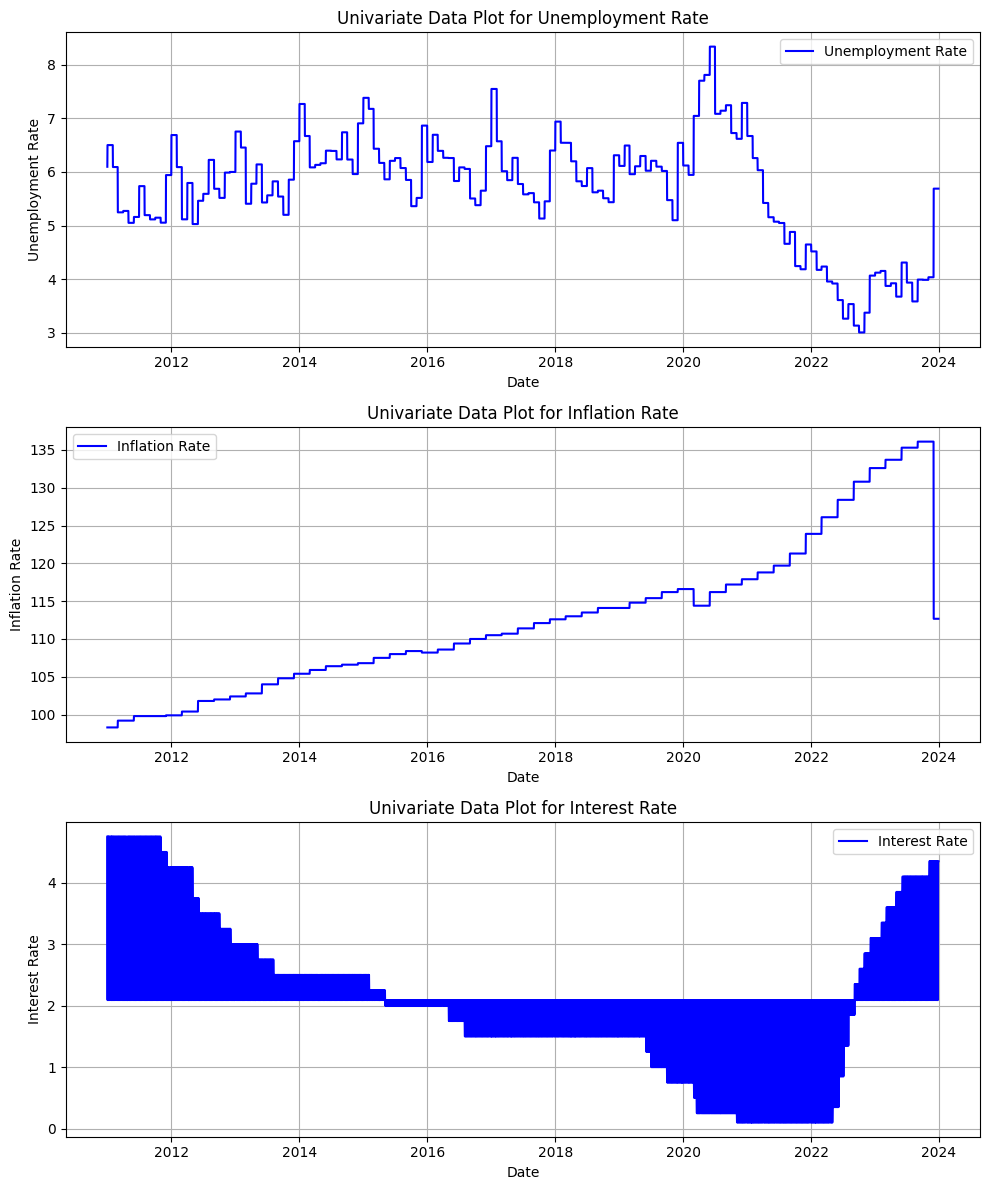

In [13]:
import matplotlib.pyplot as plt

# Generate a univariate plot for each column
def plot_univariate_data(df):
    columns = df.columns
    num_cols = len(columns)
    
    plt.figure(figsize=(10, num_cols * 4))
    
    # Loop through each column to create a plot
    for i, column in enumerate(columns):
        plt.subplot(num_cols, 1, i + 1)  
        plt.plot(df.index, df[column], label=column, color='blue')
        plt.title(f'Univariate Data Plot for {column}')
        plt.xlabel('Date')
        plt.ylabel(column)
        plt.grid(True)
        plt.legend()

    plt.tight_layout()
    plt.show()

plot_univariate_data(combined_data)


**Explanations:**

1. Univariate of Employment Rate
   
The graph shows the unemployment rate over time. The x-axis represents the date, and the y-axis represents the unemployment rate. The unemployment rate fluctuates over time, with peaks and valleys. It is clear that the unemployment rate was on a downward trend from 2012 to 2018. In 2019 there is a slight uptick in unemployment. Starting in 2020, we see a large increase in unemployment. This increase seems to have peaked around 2021 and has been steadily decreasing since.

2. Univariate of Inflation Rate

The trend reveals a steady increase in inflation starting from 2010, with a notable acceleration between 2020 and 2024. This rise could reflect global economic factors, such as the post-pandemic recovery and inflationary pressures. The step-like pattern of the graph suggests that inflation data is reported periodically, likely at monthly or quarterly intervals, making the changes appear in distinct increments rather than as a continuous curve. Overall, the inflation rate demonstrates a persistent upward trajectory throughout the period.

3. Univariate of Interest Rate

The graph shows the changes in interest rates from 2011 to 2024. In the beginning, the interest rate was above 4% but steadily declined until 2015, when it dropped to around 2%. It remained stable at this level until 2020, after which there was a sharp decrease, leading the interest rate into negative values by 2021. From 2022 onwards, the interest rate rose sharply again, reaching over 4% by 2024. The graph highlights significant periods of decline and recovery in interest rates over the years.

#### 2. Bivariate EDA

In [14]:
# correlation heatmap
correlation_data = combined_data[["Unemployment Rate", "Inflation Rate", "Interest Rate"]]

correlation_data.corr().style.background_gradient(cmap='YlOrRd')

,Unemployment Rate,Inflation Rate,Interest Rate
Unemployment Rate,1.000000,-0.577228,-0.177907
Inflation Rate,-0.577228,1.000000,-0.277134
Interest Rate,-0.177907,-0.277134,1.000000


**Unemployment Rate vs. Inflation Rate (-0.577):**

There is a moderate negative correlation, which means that when the unemployment rate goes up, the inflation rate usually goes down, and the other way around. This fits with the Phillips curve idea, where lower unemployment is linked to higher inflation, and higher unemployment tends to mean lower inflation.

**Unemployment Rate vs. Interest Rate (-0.212):**

This shows a weak negative correlation. It suggests that when unemployment increases, interest rates might drop a little, but the relationship isn’t very strong.

**Inflation Rate vs. Interest Rate (-0.330):**

There is a moderate negative correlation here. It suggests that when inflation increases, interest rates tend to go down, though the connection isn't that strong. This might seem unusual because central banks usually raise interest rates to fight inflation, but this could be based on specific patterns in the data.

In [15]:
!pip install seaborn
import seaborn as sns

!pip install squarify
import squarify 
from matplotlib import pyplot as plt

import numpy as np


Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.1.2 -> 24.2
[notice] To update, run: python3.12 -m pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.1.2 -> 24.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


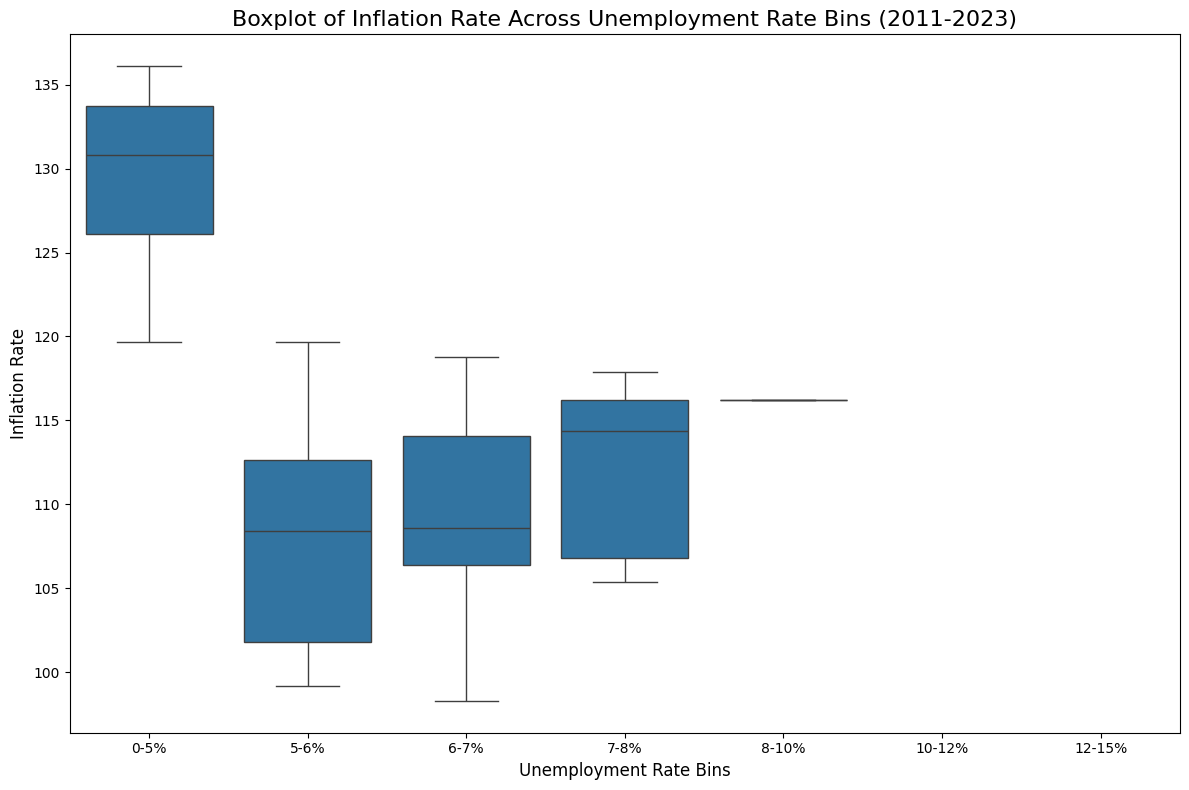

In [16]:

bins = [0, 5, 6, 7, 8, 10, 12, 15]
labels = ['0-5%', '5-6%', '6-7%', '7-8%', '8-10%', '10-12%', '12-15%']
combined_data['Unemployment Rate Binned'] = pd.cut(combined_data['Unemployment Rate'], bins=bins, labels=labels)

plt.figure(figsize=(12, 8))
sns.boxplot(data=combined_data, x='Unemployment Rate Binned', y='Inflation Rate')

plt.title('Boxplot of Inflation Rate Across Unemployment Rate Bins (2011-2023)', fontsize=16)
plt.ylabel('Inflation Rate', fontsize=12)
plt.xlabel('Unemployment Rate Bins', fontsize=12)

plt.tight_layout()
plt.show()


The boxplot shows the distribution of unemployment rates across different interest rate bins from 2011 to 2023. The interest rate bins are 0-1%, 1-3%, 3-5%, 5-7%, 7-10%, and 10-15%. The boxplot shows that the unemployment rate is generally lower when interest rates are lower. For example, the median unemployment rate for the 0-1% interest rate bin is around 6%, while the median unemployment rate for the 1-3% interest rate bin is around 6.5%. However, there is a lot of variability in unemployment rates within each interest rate bin. For example, the unemployment rate for the 1-3% interest rate bin ranges from around 3% to 8%. Overall, the boxplot suggests that there is a weak negative correlation between interest rates and unemployment rates.

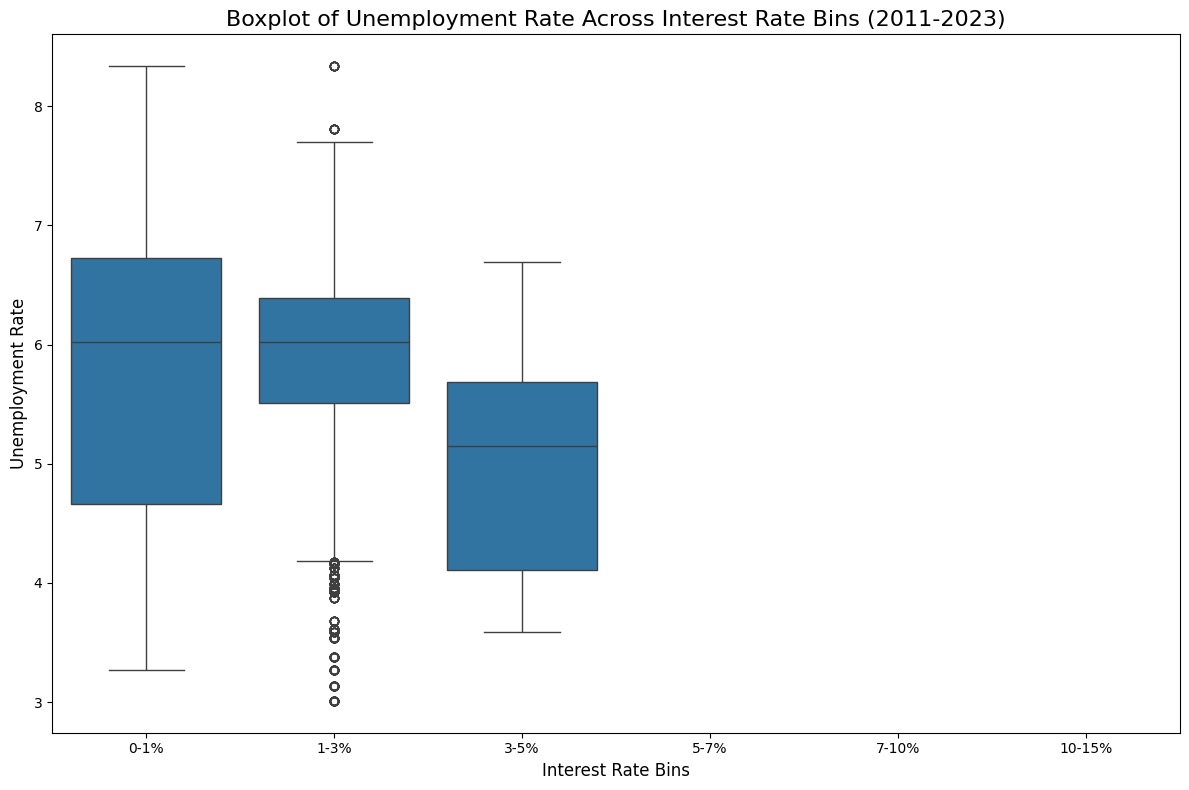

In [17]:
interest_bins = [0, 1, 3, 5, 7, 10, 15]
interest_labels = ['0-1%', '1-3%', '3-5%', '5-7%', '7-10%', '10-15%']
combined_data['Interest Rate Binned'] = pd.cut(combined_data['Interest Rate'], bins=interest_bins, labels=interest_labels)

plt.figure(figsize=(12, 8))
sns.boxplot(data=combined_data, x='Interest Rate Binned', y='Unemployment Rate')

plt.title('Boxplot of Unemployment Rate Across Interest Rate Bins (2011-2023)', fontsize=16)
plt.ylabel('Unemployment Rate', fontsize=12)
plt.xlabel('Interest Rate Bins', fontsize=12)

plt.tight_layout()
plt.show()

The boxplot shows the distribution of unemployment rates across different interest rate bins from 2011 to 2023. The interest rate bins are categorized as 0-1%, 1-3%, 3-5%, 5-7%, 7-10%, and 10-15%. The unemployment rate is highest in the 0-1% interest rate bin, with a median rate of 6.5% and a range from 3.2% to 8.5%. The unemployment rate decreases as the interest rate increases. The 1-3% bin has a median rate of 6.2% with a range of 4% to 8%. The 3-5% bin has a median rate of 5.4% with a range of 3.5% to 6.7%. The 5-7% bin has a median rate of 4.1% with a range of 3% to 5%. The 7-10% and 10-15% bins have no data points. Overall, the boxplot suggests that unemployment rates tend to be higher at lower interest rates, and lower at higher interest rates.

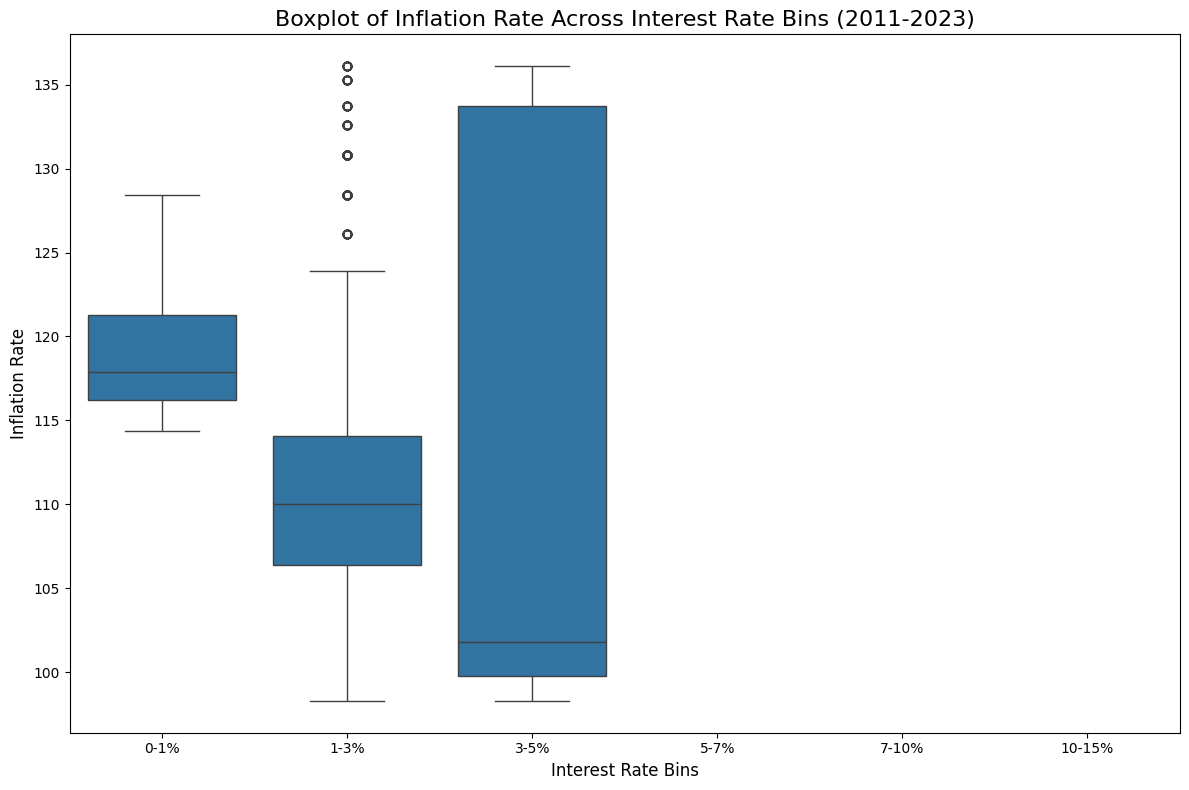

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

interest_bins = [0, 1, 3, 5, 7, 10, 15]
interest_labels = ['0-1%', '1-3%', '3-5%', '5-7%', '7-10%', '10-15%']
combined_data['Interest Rate Binned'] = pd.cut(combined_data['Interest Rate'], bins=interest_bins, labels=interest_labels)

plt.figure(figsize=(12, 8))
sns.boxplot(data=combined_data, x='Interest Rate Binned', y='Inflation Rate')

plt.title('Boxplot of Inflation Rate Across Interest Rate Bins (2011-2023)', fontsize=16)
plt.ylabel('Inflation Rate', fontsize=12)
plt.xlabel('Interest Rate Bins', fontsize=12)

plt.tight_layout()
plt.show()


The boxplot shows the distribution of inflation rates across different interest rate bins from 2011 to 2023. There are outliers for the 1-3% interest rate bin, indicating some unusually high inflation rates during this period. The inflation rates for the 3-5% interest rate bin are generally higher than the other bins, with a wider range and a higher median. The other bins show a more similar distribution of inflation rates. Overall, the plot suggests a potential relationship between interest rates and inflation, with higher interest rates possibly leading to higher inflation.

##### 3. STR decomposition

#### a. Split the data into training and testing series

In [19]:
unemployment_series = combined_data[['Unemployment Rate']]

train = unemployment_series[:'2020']  
test = unemployment_series['2021':'2023']  

#### b. STR decomposition process

**Manual Decomposition**

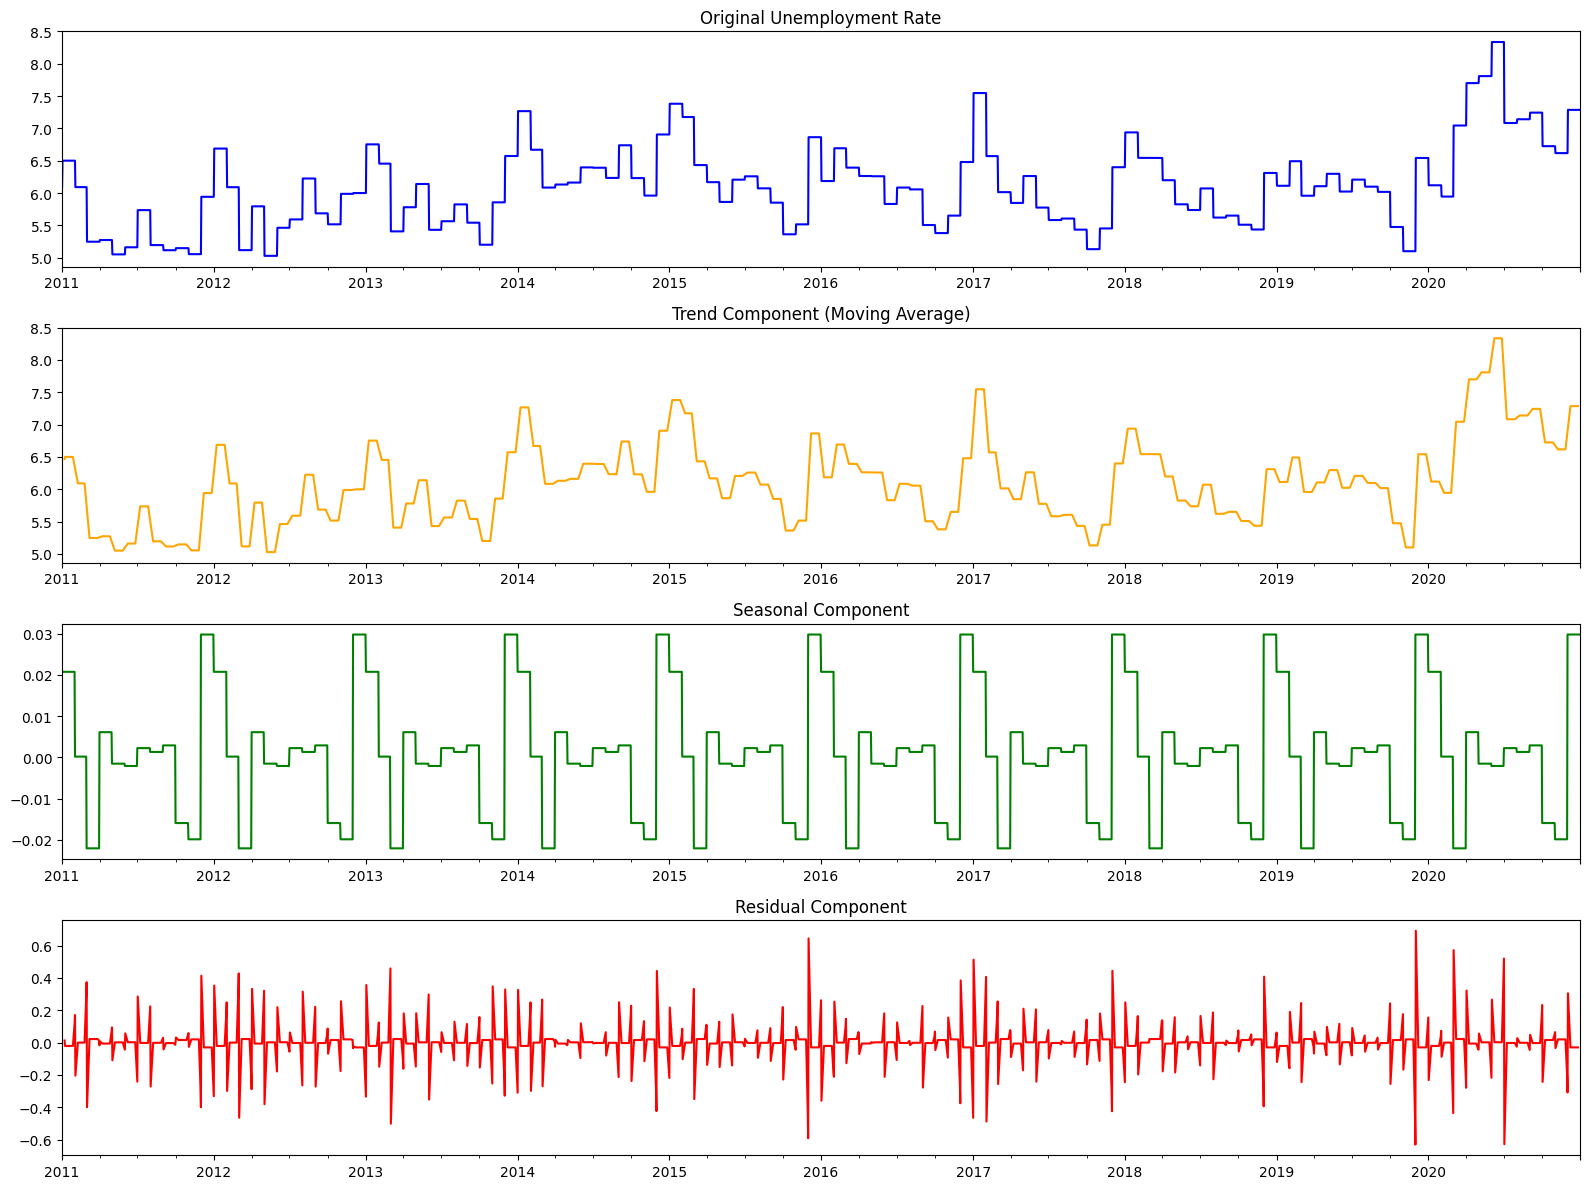

In [21]:
train.loc[:, 'Trend'] = train['Unemployment Rate'].rolling(window=12, center=True).mean()

#  Detrend the data 
train.loc[:, 'Detrended'] = train['Unemployment Rate'] - train['Trend']

# Calculate the Seasonal component 
train.loc[:, 'Month'] = train.index.month
seasonal_avg = train.groupby('Month')['Detrended'].mean()

# Assign the seasonal component to each observation
train.loc[:, 'Seasonal'] = train['Month'].apply(lambda x: seasonal_avg[x])

# Calculate the Residual
train.loc[:, 'Residual'] = train['Unemployment Rate'] - train['Trend'] - train['Seasonal']

fig, ax_str = plt.subplots(4, figsize=(16, 12))
train['Unemployment Rate'].plot(ax=ax_str[0], title='Original Unemployment Rate', color='blue')
train['Trend'].plot(ax=ax_str[1], title='Trend Component (Moving Average)', color='orange')
train['Seasonal'].plot(ax=ax_str[2], title='Seasonal Component', color='green')
train['Residual'].plot(ax=ax_str[3], title='Residual Component', color='red')

plt.tight_layout()
plt.show()

**Automated Decomposition**

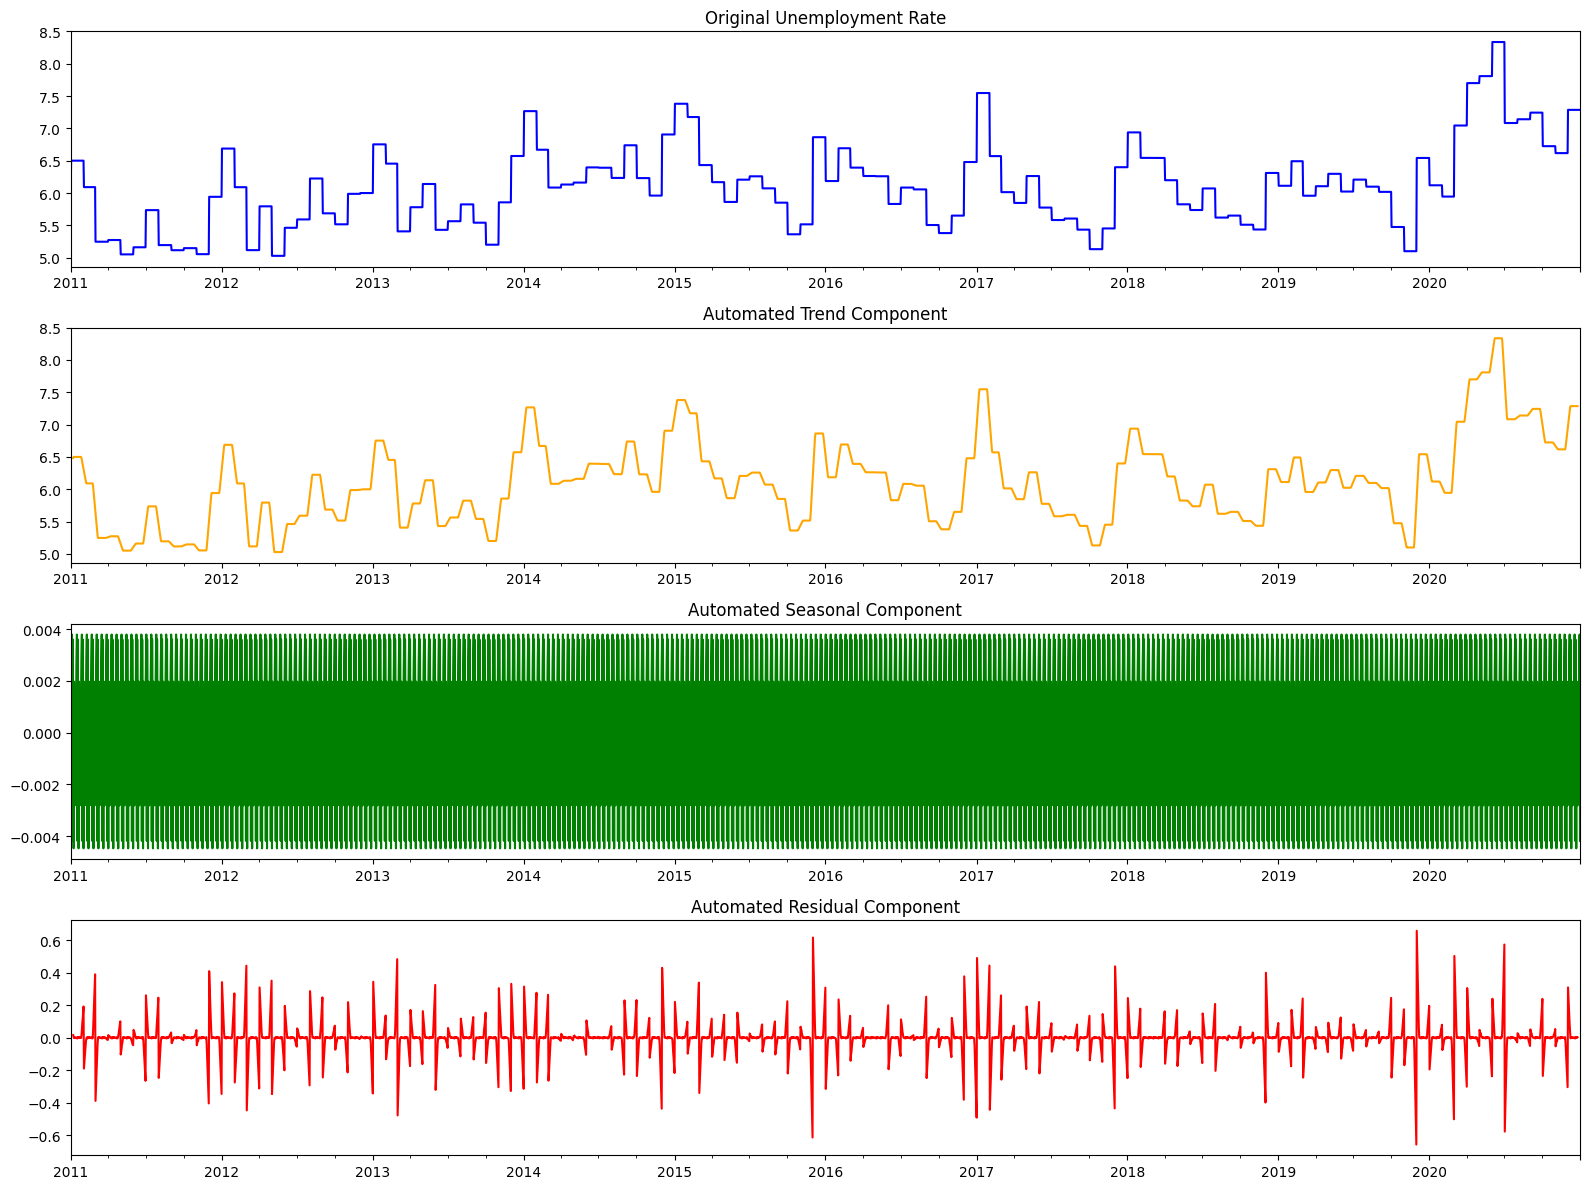

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose


decomposition = seasonal_decompose(train['Unemployment Rate'], model='additive', period=12)  # assuming monthly data
automated_trend = decomposition.trend
automated_seasonal = decomposition.seasonal
automated_residual = decomposition.resid

fig, ax = plt.subplots(4, figsize=(16, 12))
train['Unemployment Rate'].plot(ax=ax[0], title='Original Unemployment Rate', color='blue')
automated_trend.plot(ax=ax[1], title='Automated Trend Component', color='orange')
automated_seasonal.plot(ax=ax[2], title='Automated Seasonal Component', color='green')
automated_residual.plot(ax=ax[3], title='Automated Residual Component', color='red')

plt.tight_layout()
plt.show()


**Interpretation and Validation**

The manual decomposition method provides more flexibility and control compared to the automated seasonal_decompose approach. By using a 12-month moving average for trend extraction, it allows for a more accurate representation of shifts in the unemployment rate. Additionally, calculating the seasonal component by averaging detrended values for each specific month creates a more tailored seasonal pattern based on the dataset’s actual variations. In contrast, the automated method uses default settings, which might overlook smaller changes and provide less precise results.

Another advantage of the manual approach is its ability to handle missing or irregular data more effectively. By manually applying the rolling window and detrending steps, it offers greater flexibility to manage anomalies in the data, leading to more accurate component estimation. The automated method may not handle irregularities as well, which could reduce the accuracy of the trend and seasonal components. Furthermore, the manual decomposition often results in residuals that are more random, indicating a clearer separation of the trend and seasonal components.

#### 4. Timeseries Models

##### A. Fit an ARIMA model for the trend-cycle component of STR decomposition of the training data and interpret the estimated model parameters.

First ARIMA Model
                               SARIMAX Results                                
Dep. Variable:                  Trend   No. Observations:                 3642
Model:                 ARIMA(1, 2, 0)   Log Likelihood               11243.969
Date:                Fri, 25 Oct 2024   AIC                         -22483.938
Time:                        02:52:05   BIC                         -22471.539
Sample:                    01-07-2011   HQIC                        -22479.522
                         - 12-26-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1       3.426e-08    8.4e-18   4.08e+09      0.000    3.43e-08    3.43e-08
sigma2         0.0001   6.08e-07    199.745      0.000       0.000       0.000
Ljung-Box (L1) (Q):               

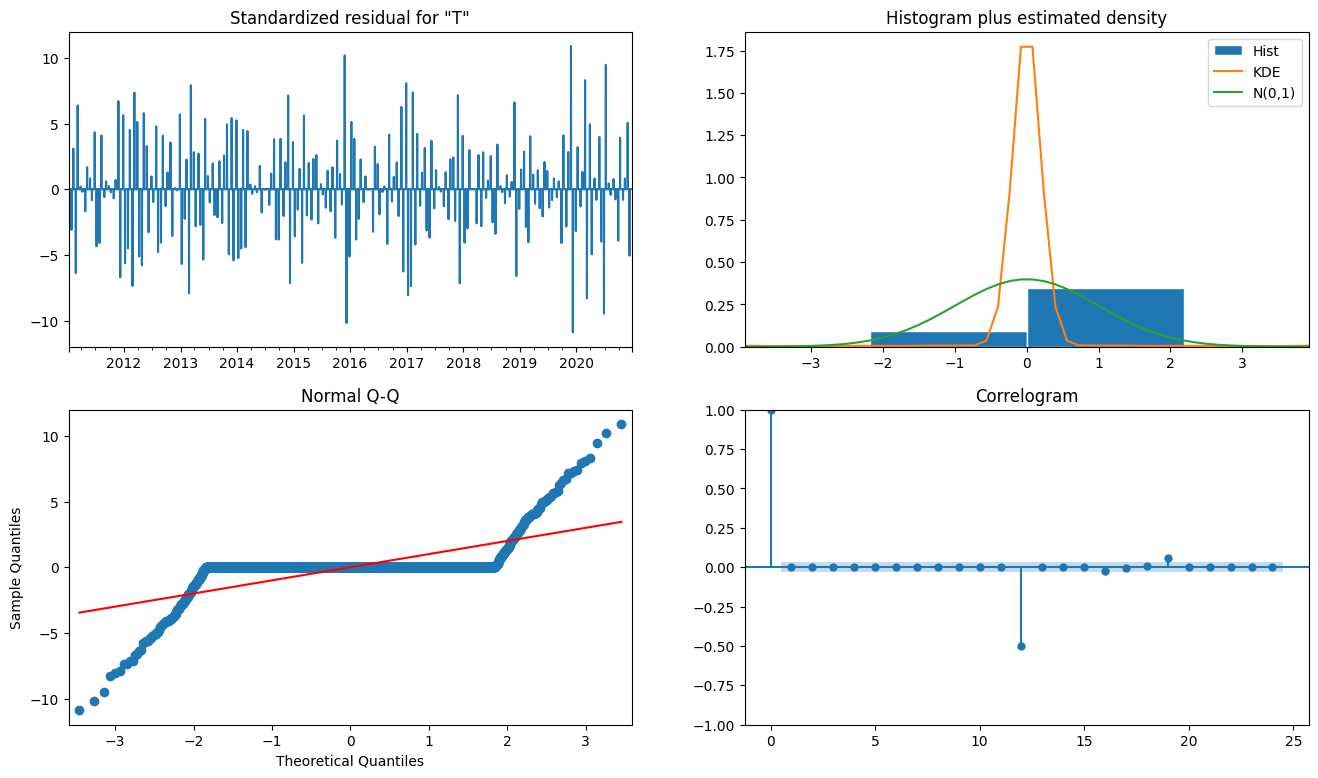

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

print("First ARIMA Model")
trend_series = train['Trend'].dropna() 
arima_model1 = ARIMA(trend_series, order=(1, 2, 0)).fit()
print(arima_model1.summary())
fig = plt.figure(figsize=(16, 9))
fig = arima_model1.plot_diagnostics(fig=fig, lags=24)

Higher Order Model
                               SARIMAX Results                                
Dep. Variable:                  Trend   No. Observations:                 3642
Model:                 ARIMA(2, 2, 0)   Log Likelihood               11243.969
Date:                Fri, 25 Oct 2024   AIC                         -22481.938
Time:                        02:52:13   BIC                         -22463.339
Sample:                    01-07-2011   HQIC                        -22475.313
                         - 12-26-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1      -1.367e-08   1.17e-18  -1.17e+10      0.000   -1.37e-08   -1.37e-08
ar.L2       3.643e-10    5.5e-20   6.62e+09      0.000    3.64e-10    3.64e-10
sigma2         0.0001   6.08e-07 

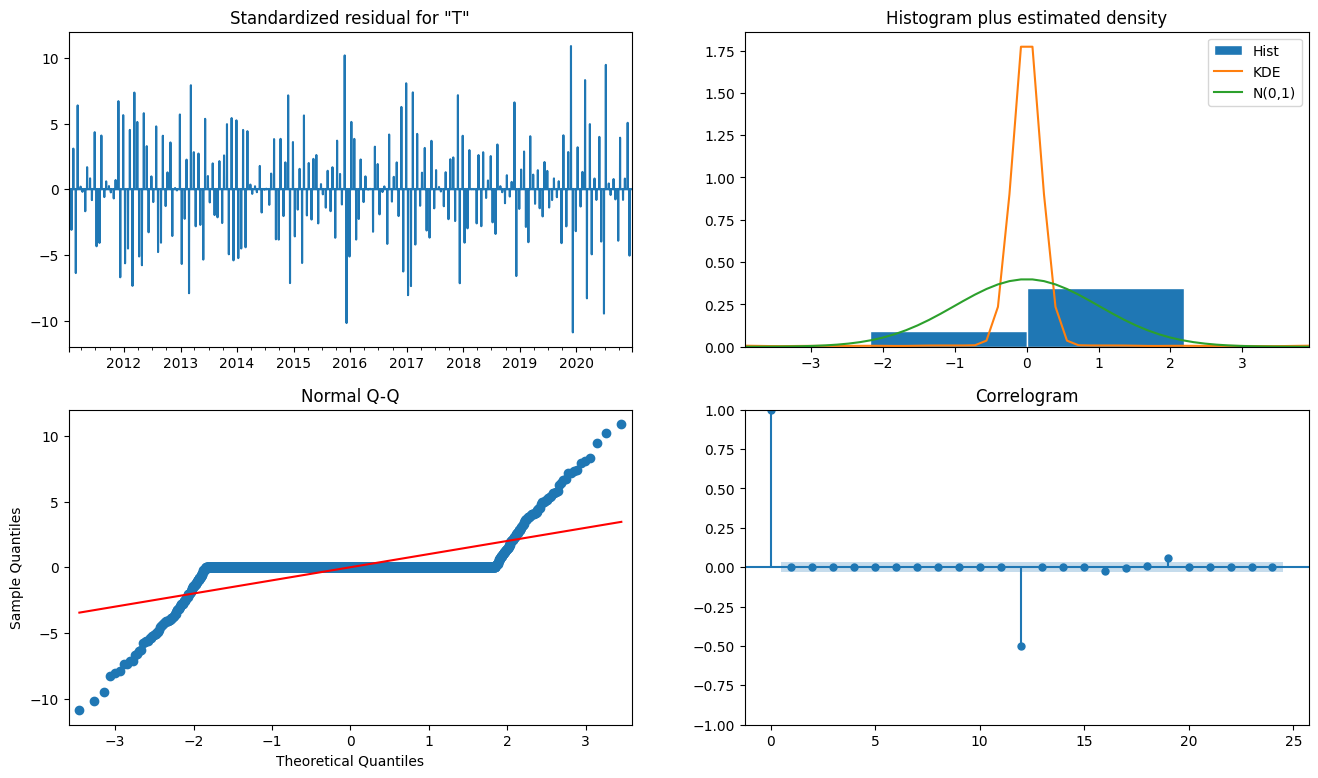

In [24]:
print("Higher Order Model")
arima_model2 = ARIMA(trend_series, order=(2, 2, 0)).fit()
print(arima_model2.summary())
fig = plt.figure(figsize=(16, 9))
fig = arima_model2.plot_diagnostics(fig=fig, lags=24)

                               SARIMAX Results                                
Dep. Variable:                  Trend   No. Observations:                 3642
Model:                 ARIMA(2, 2, 1)   Log Likelihood               11243.969
Date:                Fri, 25 Oct 2024   AIC                         -22479.938
Time:                        02:52:20   BIC                         -22455.139
Sample:                    01-07-2011   HQIC                        -22471.105
                         - 12-26-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2345   9.26e-18  -2.53e+16      0.000      -0.234      -0.234
ar.L2       -1.81e-08   3.95e-17  -4.59e+08      0.000   -1.81e-08   -1.81e-08
ma.L1          0.2345   9.26e-18   2.53e+16      0.0

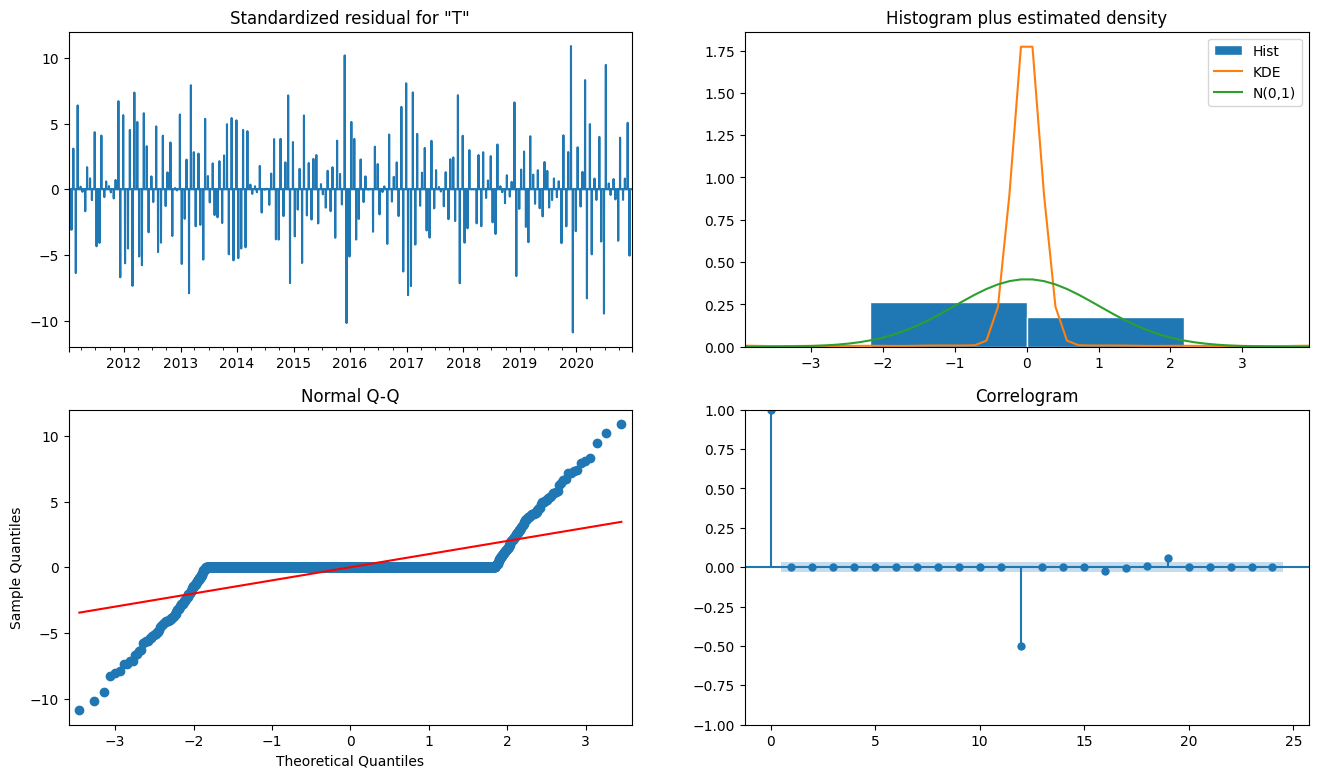

In [25]:
arima_model3 = ARIMA(trend_series, order=(2, 2, 1)).fit()
print(arima_model3.summary())
fig = plt.figure(figsize=(16, 9))
fig = arima_model3.plot_diagnostics(fig=fig, lags=24)

**Interpretation**

From the results, Model 1 (ARIMA(1, 2, 0)) has the lowest AIC and BIC, which suggests it's a better fit based on these metrics. However, the AR(1) coefficient is extremely small, which makes me question if this model is really the best choice—it might be over-differencing the data. Although the residuals don’t show autocorrelation, the non-normality issue suggests the model isn’t fully capturing all the data patterns.

On the other hand, Model 3 (ARIMA(2, 2, 1)) has more meaningful parameters, with significant AR(1) and MA(1) terms, making it easier to understand. Even though its AIC and BIC are a bit higher, it seems to better represent the data’s structure, though some improvements could still be made, like adding seasonal components.

##### B. Forecasts of Queensland unemployment for the test data series

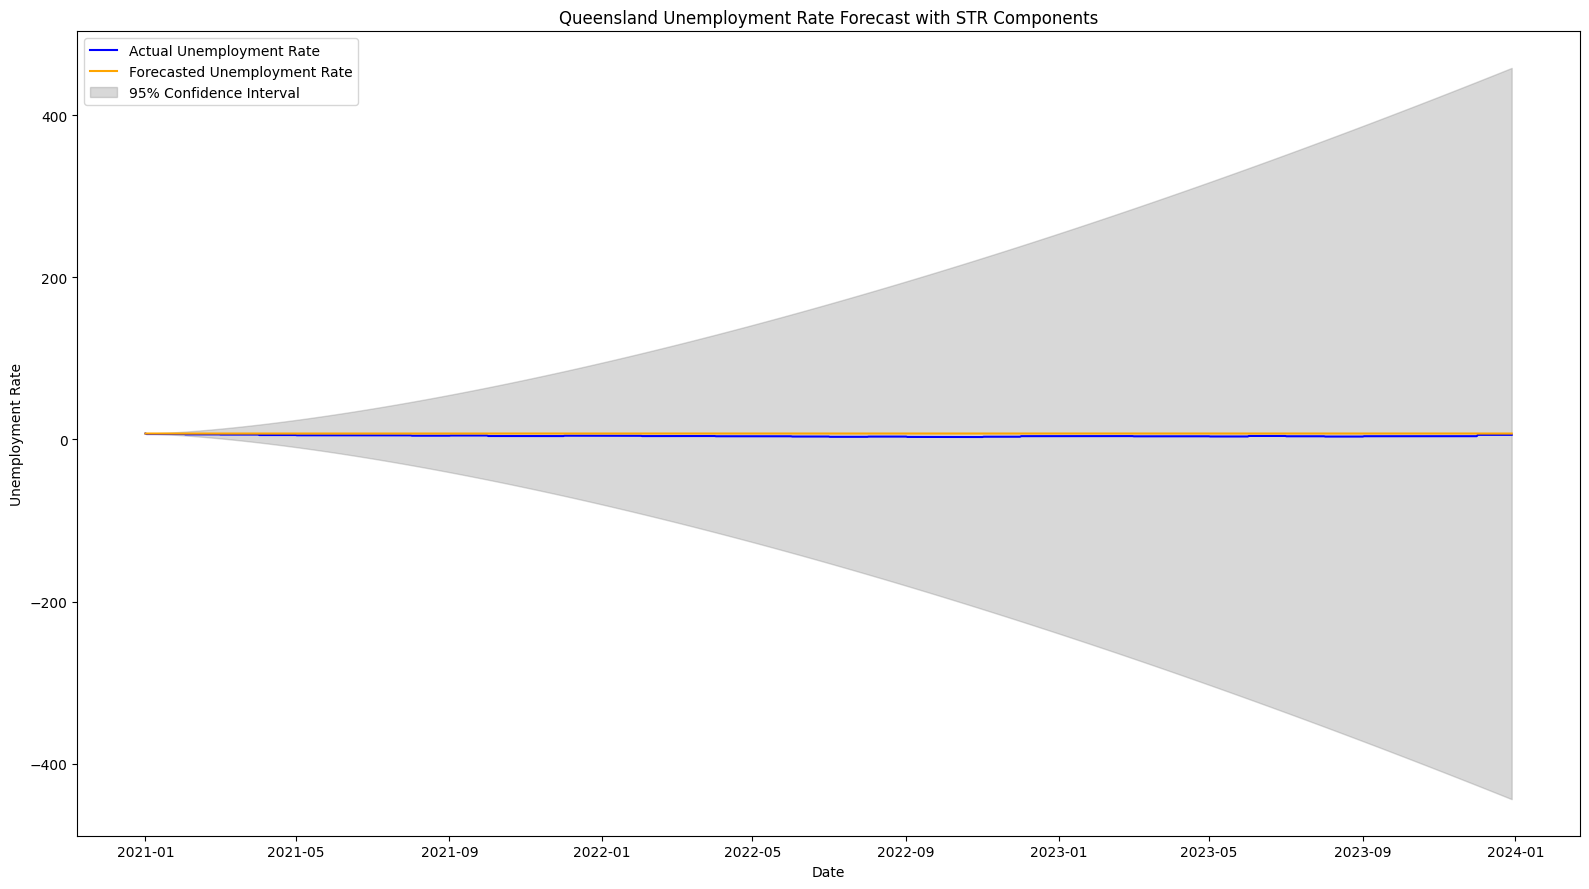

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

trend_series = train['Trend'].dropna()
arima_model3 = ARIMA(trend_series, order=(2, 2, 1)).fit()

forecast_steps = len(test)  # Number of steps to forecast based on test data
forecast_result = arima_model3.get_forecast(steps=forecast_steps)  # Use get_forecast instead of forecast

forecast_trend = forecast_result.predicted_mean
conf_int_trend = forecast_result.conf_int(alpha=0.05)

# Extend the Seasonal Component for the Test Period
seasonal_pattern = train['Seasonal'][-12:]  # Last 12 months of seasonal component
forecast_seasonal = np.tile(seasonal_pattern, int(np.ceil(forecast_steps / 12)))[:forecast_steps]

# Combine the Trend and Seasonal Forecasts
forecast_unemployment = forecast_trend + forecast_seasonal

# Calculate confidence intervals for the total forecast
lower_bound = conf_int_trend.iloc[:, 0] + forecast_seasonal
upper_bound = conf_int_trend.iloc[:, 1] + forecast_seasonal

# Visualize the Forecast and Include Uncertainty Intervals
plt.figure(figsize=(16, 9))
plt.plot(test.index, test['Unemployment Rate'], label='Actual Unemployment Rate', color='blue')
plt.plot(test.index, forecast_unemployment, label='Forecasted Unemployment Rate', color='orange')
plt.fill_between(test.index, lower_bound, upper_bound, color='gray', alpha=0.3, label='95% Confidence Interval')
plt.title('Queensland Unemployment Rate Forecast with STR Components')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate')
plt.legend()

plt.tight_layout()
plt.show()


#### 5. Pure forecasters

##### A.  Pure forecasting method to predict the trend component of the unemployment training data.

In [28]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow import keras
import matplotlib.pyplot as plt

trend_series = train['Trend'].dropna()

scaler = MinMaxScaler()
trend_series_scaled = scaler.fit_transform(trend_series.values.reshape(-1, 1))
X = np.array([trend_series_scaled[i:i+4] for i in range(len(trend_series_scaled) - 4)])
y = trend_series_scaled[4:]

# Split data into training and testing sets
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Define and compile the model
model = keras.Sequential([
    keras.layers.Input(shape=(4,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1)
])
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mse')
model.summary()

# Train the model
model.fit(X_train, y_train, epochs=20, batch_size=20, shuffle=False)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 385 (1.50 KB)

 Trainable params: 385 (1.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 1s 563us/step - loss: 0.0078 
Epoch 2/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 448us/step - loss: 1.9994e-04
Epoch 3/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 434us/step - loss: 1.5686e-04
Epoch 4/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 449us/step - loss: 1.2637e-04
Epoch 5/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 435us/step - loss: 9.9778e-05
Epoch 6/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 472us/step - loss: 7.8800e-05
Epoch 7/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 447us/step - loss: 6.5930e-05
Epoch 8/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 426us/step - loss: 6.1649e-05
Epoch 9/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 424us/step - loss: 6.2021e-05
Epoch 10/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 470us/step - loss: 6.1800e-05
Epoch 11/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 435us/step - loss: 6.3838e-05
Epoch 12/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 431us/step - loss: 6.3140e-05
Epoch 13/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 483us/step - loss: 5.8436e-05
Epoch 14/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 462us/

##### B.  Forecasts of Queensland unemployment for the test data series

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1000us/step


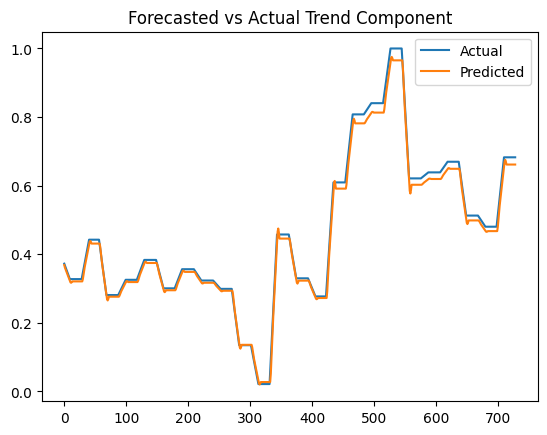

In [19]:
# Predicting the test set values
y_pred = model.predict(X_test)

# Plot actuals vs predictions
plt.plot(y_test, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.title("Forecasted vs Actual Trend Component")
plt.show()


In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense


if combined_data.empty or 'Unemployment Rate' not in combined_data.columns:
    raise ValueError("combined_data is empty or missing 'Unemployment Rate' column.")

train_size = int(len(combined_data) * 0.8)
train = combined_data.iloc[:train_size]
test = combined_data.iloc[train_size:]

if 'Unemployment Rate' not in train.columns or 'Unemployment Rate' not in test.columns:
    raise KeyError("The column 'Unemployment Rate' is missing from the dataset.")

y_train = train['Unemployment Rate'].values  # Target variable
X_train = np.arange(len(y_train)).reshape(-1, 1)  # Time steps as features
y_test = test['Unemployment Rate'].values
X_test = np.arange(len(y_train), len(y_train) + len(y_test)).reshape(-1, 1)

model = Sequential()
model.add(Dense(64, activation='relu', input_dim=1))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))  

model.compile(optimizer='adam', loss='mean_squared_error')

try:
    history = model.fit(X_train, y_train, epochs=50, batch_size=4, verbose=1)  # Adjusted epochs and batch size
except ValueError as e:
    print(f"Error occurred during model fitting: {e}")
    raise

try:
    predictions = model.predict(X_train, verbose=0)
    residuals = y_train - predictions.flatten()
except Exception as e:
    print(f"Error occurred during prediction: {e}")
    raise

def multistep_prediction(H, model, X_start):
    y_pred_multi = []
    X_input = X_start.reshape(1, -1)  # Ensure input shape is (1, number_of_features)

    for _ in range(H):
        pred = model.predict(X_input, verbose=0).flatten()[0]  # Predict and flatten
        y_pred_multi.append(pred)
        
        # Update input for next prediction
        X_input = np.array([[pred]])  # Update the input for the next step

    return np.array(y_pred_multi)

# Bootstrap iterations
K = 20
H = len(y_test)

X_pred = X_test[0, :]  
y_pred_bootstrap = []

# Generate bootstrap predictions
for k in range(K):
    y_pred_multi = multistep_prediction(H, model, X_pred)
    y_pred_bootstrap.append(y_pred_multi)

# Check if 'Seasonal Component' exists in test DataFrame
if 'Seasonal Component' in test.columns:
    seasonal_component = np.tile(test['Seasonal Component'].values, (K, 1))
else:
    print("Warning: 'Seasonal Component' column not found. Please ensure it exists or create it.")
    seasonal_component = np.zeros((K, H))  # Placeholder if you want to proceed without it

# Final predictions by adding seasonal component
final_predictions = np.array(y_pred_bootstrap) + seasonal_component

# Prepare the DataFrame for bootstrap predictions
bootstrap_predictions = pd.DataFrame(index=test.index)

for pctl in range(0, 101, 10):
    bootstrap_predictions[str(pctl)] = np.percentile(final_predictions, pctl, axis=0)

bootstrap_predictions.rename(columns={'50': "median"}, inplace=True)
bootstrap_predictions['actuals'] = y_test

# Visualizing bootstrapped interval forecasts
fig, ax = plt.subplots(figsize=(12, 6))
bootstrap_predictions['actuals'].plot(color='blue', label='Actuals')
bootstrap_predictions['median'].plot(color='red', label='Median prediction')
bootstrap_predictions['10'].plot(color='grey', label='10th percentile')
bootstrap_predictions['90'].plot(color='grey', label='90th percentile')

# Fill between for uncertainty range
plt.fill_between(bootstrap_predictions.index, bootstrap_predictions['10'], bootstrap_predictions['90'], color='grey', alpha=0.3)
plt.legend(loc='upper left', fontsize=12)
plt.title('Bootstrap Forecasts with Seasonal Component and Uncertainty Intervals')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate')
plt.show()

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/lib/python3.12/contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(value)


TypeError: 'NoneType' object is not iterable

#### 6. Interest rate projections affect the forecasts

##### A. Generate a series of values corresponding to a hypothetical reduction of interest rates by 0.5% for the next six months beyond the end of the test data, and a second series of values corresponding to interest rates remaining at their current level for the same duration

In [68]:
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt

combined_data['Date'] = pd.to_datetime(combined_data.iloc[:, 0])
combined_data.set_index('Date', inplace=True)
combined_data.sort_index(inplace=True)
combined_data = combined_data[~combined_data.index.duplicated(keep='first')]
combined_data = combined_data.asfreq('MS') 

last_interest_rate = combined_data['Interest Rate'].iloc[-1]

# 1. Hypothetical reduction of interest rates by 0.5%
interest_rate_reduced = pd.Series([last_interest_rate - 0.5] * 6, 
                                  index=pd.date_range(start=combined_data.index.max() + pd.DateOffset(months=1), periods=6, freq='MS'))

# 2. Interest rates remain at the current level
interest_rate_stable = pd.Series([last_interest_rate] * 6, 
                                 index=pd.date_range(start=combined_data.index.max() + pd.DateOffset(months=1), periods=6, freq='MS'))

# Create a DataFrame to show both interest rate projections side by side
interest_rate_table = pd.DataFrame({
    'Date': interest_rate_reduced.index,
    'Interest Rate Reduced by 0.5%': interest_rate_reduced.values,
    'Interest Rate Remain': interest_rate_stable.values
})

# Display the interest rate projection table
print("Interest Rate Projections for the Next Six Months:")
print(interest_rate_table)

Interest Rate Projections for the Next Six Months:
                           Date  Interest Rate Reduced by 0.5%  \
0 1970-02-01 00:00:00.000000003                            3.1   
1 1970-03-01 00:00:00.000000003                            3.1   
2 1970-04-01 00:00:00.000000003                            3.1   
3 1970-05-01 00:00:00.000000003                            3.1   
4 1970-06-01 00:00:00.000000003                            3.1   
5 1970-07-01 00:00:00.000000003                            3.1   

   Interest Rate Remain  
0                   3.6  
1                   3.6  
2                   3.6  
3                   3.6  
4                   3.6  
5                   3.6  


##### B. Forecasts

/tmp/ipykernel_341524/186346839.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start=train_data.index[-1] + pd.Timedelta(days=1), periods=6, freq='M')
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:1233: RuntimeWarning: invalid value encountered in divide
  np.inner(score_obs, score_obs) /
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/us

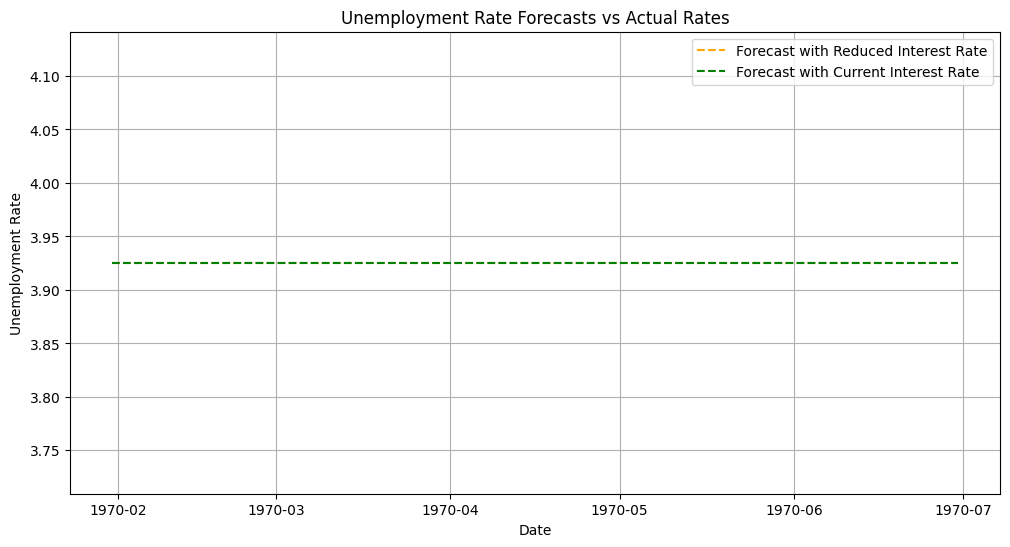

In [73]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
import pandas as pd

train_data = combined_data.copy()
current_interest_rate = train_data['Interest Rate'].iloc[-1]  
reduced_interest_rate = current_interest_rate - 0.5  

# Create DataFrame for future values
future_dates = pd.date_range(start=train_data.index[-1] + pd.Timedelta(days=1), periods=6, freq='M')
interest_rates_df = pd.DataFrame(index=future_dates)
interest_rates_df['Reduced Interest Rate'] = reduced_interest_rate
interest_rates_df['Current Interest Rate'] = current_interest_rate

# Forward fill the Inflation Rate from the training data for the forecast period
interest_rates_df['Inflation Rate'] = train_data['Inflation Rate'].iloc[-1]  

# Fit the ARIMAX model for the reduced interest rate scenario
model_reduced = SARIMAX(train_data['Unemployment Rate'],
                         exog=train_data[['Inflation Rate', 'Interest Rate']],
                         order=(2, 1, 2)) 
model_reduced_fit = model_reduced.fit(disp=False)

# Generate predictions for the reduced interest rate scenario
exog_reduced = interest_rates_df[['Reduced Interest Rate', 'Inflation Rate']]
forecast_reduced = model_reduced_fit.get_forecast(steps=6, exog=exog_reduced)
forecast_reduced_series = forecast_reduced.predicted_mean
forecast_reduced_series.index = future_dates 

# Fit the ARIMAX model for the current interest rate scenario
model_current = SARIMAX(train_data['Unemployment Rate'],
                         exog=train_data[['Inflation Rate', 'Interest Rate']],
                         order=(2, 1, 2))
model_current_fit = model_current.fit(disp=False)

# Generate predictions for the current interest rate scenario
exog_current = interest_rates_df[['Current Interest Rate', 'Inflation Rate']]
forecast_current = model_current_fit.get_forecast(steps=6, exog=exog_current)
forecast_current_series = forecast_current.predicted_mean
forecast_current_series.index = future_dates  # Use future dates for the forecast

plt.figure(figsize=(12, 6))
plt.plot(forecast_reduced_series, label='Forecast with Reduced Interest Rate', color='orange', linestyle='--')
plt.plot(forecast_current_series, label='Forecast with Current Interest Rate', color='green', linestyle='--')

plt.xlabel('Date')
plt.ylabel('Unemployment Rate')
plt.title('Unemployment Rate Forecasts vs Actual Rates')
plt.legend()
plt.grid()
plt.show()
